# Методы дискретной оптимизации
## Домашняя работа 1 - Остовные деревья

### Вариант: [ФАМИЛИЯ]

In [58]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import csv

# ============================================
# ВВЕДИТЕ СВОЮ ФАМИЛИЮ ЗДЕСЬ
# ============================================
SURNAME = "Чернев"  # <-- измените на свою фамилию
# ============================================

## 1. Загрузка данных из CSV

In [59]:
def parse_matrix(matrix_str):
    """Парсинг строки матрицы из CSV"""
    matrix_str = matrix_str.replace('{', '[').replace('}', ']')
    matrix = eval(matrix_str)
    return np.array(matrix)

def load_data(csv_path, surname):
    """Загрузка данных студента по фамилии"""
    with open(csv_path, 'r', encoding='utf-8') as f:
        reader = csv.reader(f, delimiter=';')
        for row in reader:
            if len(row) >= 2:
                # ФИО во втором столбце
                fio = row[1].strip()
                last_name = fio.split()[0]  # Берём фамилию
                if last_name == surname:
                    variant_num = int(row[0])
                    matrix_str = row[2]
                    matrix = parse_matrix(matrix_str)
                    return variant_num, fio, matrix
    raise ValueError(f"Студент с фамилией '{surname}' не найден")


csv_path = '/Users/nachernev/Desktop/sem6/IO/мдо ДЗ1 - ИУ5-64б.csv'
variant, fio, adj_matrix = load_data(csv_path, SURNAME)

print(f"Вариант №{variant}: {fio}")
print(f"\nМатрица смежности ({len(adj_matrix)}x{len(adj_matrix)}):")
print(adj_matrix)

Вариант №20: Чернев Н А

Матрица смежности (9x9):
[[0 0 5 0 0 0 0 7 0]
 [0 0 3 0 0 4 2 0 6]
 [5 3 0 3 7 0 0 7 0]
 [0 0 3 0 3 1 0 5 0]
 [0 0 7 3 0 7 7 2 0]
 [0 4 0 1 7 0 4 5 7]
 [0 2 0 0 7 4 0 3 5]
 [7 0 7 5 2 5 3 0 0]
 [0 6 0 0 0 7 5 0 0]]


## 2. Матрица Кирхгофа (Лапласиан графа)

Матрица Кирхгофа:
[[12  0 -5  0  0  0  0 -7  0]
 [ 0 15 -3  0  0 -4 -2  0 -6]
 [-5 -3 25 -3 -7  0  0 -7  0]
 [ 0  0 -3 12 -3 -1  0 -5  0]
 [ 0  0 -7 -3 26 -7 -7 -2  0]
 [ 0 -4  0 -1 -7 28 -4 -5 -7]
 [ 0 -2  0  0 -7 -4 21 -3 -5]
 [-7  0 -7 -5 -2 -5 -3 29  0]
 [ 0 -6  0  0  0 -7 -5  0 18]]


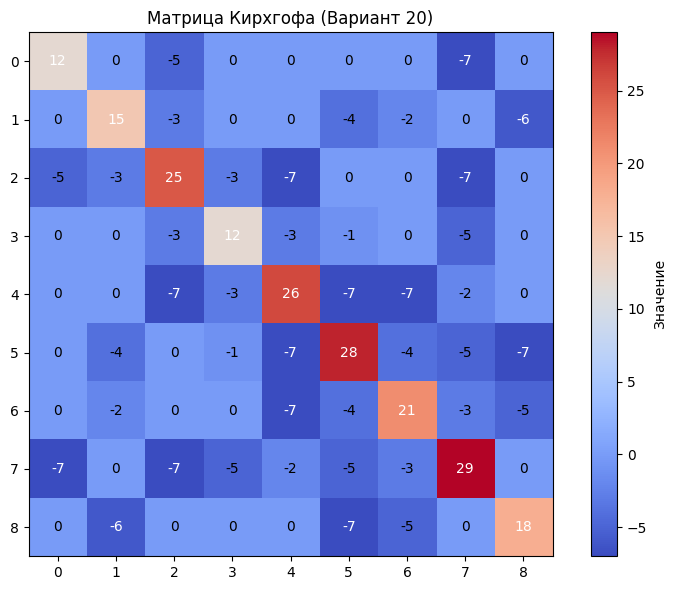

In [60]:
def kirchhoff_matrix(adj_matrix):
    """
    Построение матрицы Кирхгофа (Лапласиана) графа.
    L[i,i] = степень вершины i (сумма весов инцидентных рёбер)
    L[i,j] = -weight(i,j) для i != j
    """
    n = len(adj_matrix)
    L = np.zeros((n, n), dtype=int)
    
    for i in range(n):
        degree = 0
        for j in range(n):
            if i != j:
                weight = adj_matrix[i, j]
                if weight > 0:
                    degree += weight
                    L[i, j] = -weight
        L[i, i] = degree
    
    return L

# Строим матрицу Кирхгофа
K = kirchhoff_matrix(adj_matrix)

print("Матрица Кирхгофа:")
print(K)

# Визуализация
plt.figure(figsize=(8, 6))
plt.imshow(K, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Значение')
plt.title(f'Матрица Кирхгофа (Вариант {variant})')
plt.xticks(range(len(K)))
plt.yticks(range(len(K)))

# Добавляем значения в ячейки
for i in range(len(K)):
    for j in range(len(K)):
        plt.text(j, i, str(int(K[i, j])), ha='center', va='center',
                color='white' if abs(K[i, j]) > 5 else 'black')

plt.tight_layout()
plt.show()

## 3. Количество остовных деревьев (теорема Кирхгофа)

In [61]:
def count_spanning_trees(kirchhoff_mat):
    """
    Подсчёт количества остовных деревьев с помощью теоремы Кирхгофа.
    Количество остовных деревьев равно любому алгебраическому дополнению
    матрицы Кирхгофа (определитель матрицы с вычеркнутой строкой и столбцом).
    """
    # Вычёркиваем первую строку и первый столбец
    minor = kirchhoff_mat[1:, 1:]
    # Вычисляем определитель
    det = round(np.linalg.det(minor))
    return abs(det)

num_trees = count_spanning_trees(K)

print(f"\nКоличество остовных деревьев: {num_trees:,}")
print(f"(вычислено через алгебраическое дополнение матрицы Кирхгофа)")


Количество остовных деревьев: 3,304,071,765
(вычислено через алгебраическое дополнение матрицы Кирхгофа)


## 4. Алгоритм Краскала - Минимальное остовное дерево

In [62]:
class DSU:
    """Система непересекающихся множеств (DSU) с ранговой эвристикой"""
    
    def __init__(self, n):
        self.parent = list(range(n))
        self.rank = [0] * n
        self.n = n
    
    def find(self, x):
        """Найти корень множества с путевой компрессией"""
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]
    
    def union(self, x, y):
        """Объединить два множества. Возвращает True если были разные множества"""
        root_x = self.find(x)
        root_y = self.find(y)
        
        if root_x == root_y:
            return False
        
        # Объединение по рангу
        if self.rank[root_x] < self.rank[root_y]:
            self.parent[root_x] = root_y
        elif self.rank[root_x] > self.rank[root_y]:
            self.parent[root_y] = root_x
        else:
            self.parent[root_y] = root_x
            self.rank[root_x] += 1
        
        return True
    
    def get_partitions(self):
        """Возвращает текущее разбиение вершин на множества"""
        partitions = {}
        for i in range(self.n):
            root = self.find(i)
            if root not in partitions:
                partitions[root] = []
            partitions[root].append(i)
        return list(partitions.values())


def kruskal_with_steps(adj_matrix):
    """
    Алгоритм Краскала с пошаговой визуализацией.
    Возвращает: рёбра МОД, общий вес, история шагов
    """
    n = len(adj_matrix)
    
    # Собираем все рёбра (только верхний треугольник, чтобы не дублировать)
    edges = []
    for i in range(n):
        for j in range(i + 1, n):
            weight = adj_matrix[i, j]
            if weight > 0:  # Есть ребро
                edges.append((weight, i, j))
    
    # Сортируем рёбра по весу
    edges.sort()
    
    dsu = DSU(n)
    mst_edges = []
    mst_weight = 0
    steps = []  # История шагов
    
    for weight, u, v in edges:
        # Получаем разбиение ДО попытки добавить ребро
        partition_before = [list(p) for p in dsu.get_partitions()]
        
        # Пытаемся добавить ребро
        added = dsu.union(u, v)
        
        # Получаем разбиение ПОСЛЕ
        partition_after = [list(p) for p in dsu.get_partitions()]
        
        step_info = {
            'edge': (u, v),
            'weight': weight,
            'added': added,
            'partition_before': partition_before,
            'partition_after': partition_after
        }
        steps.append(step_info)
        
        if added:
            mst_edges.append((u, v, weight))
            mst_weight += weight
            
            # Проверяем, построено ли уже дерево
            if len(mst_edges) == n - 1:
                break
    
    return mst_edges, mst_weight, steps


# Запускаем алгоритм Краскала
mst_edges, mst_weight, steps = kruskal_with_steps(adj_matrix)

print(f"\n{'='*60}")
print("АЛГОРИТМ КРАСКАЛА - ПОШАГОВОЕ ВЫПОЛНЕНИЕ")
print(f"{'='*60}")
print(f"\nВсего вершин: {len(adj_matrix)}")
print(f"Всего рёбер в графе: {sum(1 for i in range(len(adj_matrix)) for j in range(i+1, len(adj_matrix)) if adj_matrix[i,j] > 0)}")
print(f"\nОтсортированный список рёбер (по возрастанию веса):")


АЛГОРИТМ КРАСКАЛА - ПОШАГОВОЕ ВЫПОЛНЕНИЕ

Всего вершин: 9
Всего рёбер в графе: 20

Отсортированный список рёбер (по возрастанию веса):


In [63]:
# Вывод всех рёбер в отсортированном порядке
all_edges = []
n = len(adj_matrix)
for i in range(n):
    for j in range(i + 1, n):
        if adj_matrix[i, j] > 0:
            all_edges.append((adj_matrix[i, j], i, j))
all_edges.sort()

for idx, (w, u, v) in enumerate(all_edges, 1):
    status = "✓ ВКЛЮЧЕНО" if any(e[0]==u and e[1]==v for e in mst_edges) else "✗ отклонено"
    print(f"{idx:2}. Ребро ({u}-{v}), вес = {w}  {status}")

 1. Ребро (3-5), вес = 1  ✓ ВКЛЮЧЕНО
 2. Ребро (1-6), вес = 2  ✓ ВКЛЮЧЕНО
 3. Ребро (4-7), вес = 2  ✓ ВКЛЮЧЕНО
 4. Ребро (1-2), вес = 3  ✓ ВКЛЮЧЕНО
 5. Ребро (2-3), вес = 3  ✓ ВКЛЮЧЕНО
 6. Ребро (3-4), вес = 3  ✓ ВКЛЮЧЕНО
 7. Ребро (6-7), вес = 3  ✗ отклонено
 8. Ребро (1-5), вес = 4  ✗ отклонено
 9. Ребро (5-6), вес = 4  ✗ отклонено
10. Ребро (0-2), вес = 5  ✓ ВКЛЮЧЕНО
11. Ребро (3-7), вес = 5  ✗ отклонено
12. Ребро (5-7), вес = 5  ✗ отклонено
13. Ребро (6-8), вес = 5  ✓ ВКЛЮЧЕНО
14. Ребро (1-8), вес = 6  ✗ отклонено
15. Ребро (0-7), вес = 7  ✗ отклонено
16. Ребро (2-4), вес = 7  ✗ отклонено
17. Ребро (2-7), вес = 7  ✗ отклонено
18. Ребро (4-5), вес = 7  ✗ отклонено
19. Ребро (4-6), вес = 7  ✗ отклонено
20. Ребро (5-8), вес = 7  ✗ отклонено


In [64]:
# Подробная пошаговая визуализация
print(f"\n{'='*60}")
print("ПОШАГОВАЯ ИСТОРИЯ ДОБАВЛЕНИЯ РЁБЕР")
print(f"{'='*60}\n")

step_num = 0
for step in steps:
    u, v = step['edge']
    w = step['weight']
    
    if step['added']:
        step_num += 1
        print(f"\n{'─'*50}")
        print(f"ШАГ {step_num}: Добавлено ребро ({u}—{v}) с весом {w}")
        print(f"{'─'*50}")
        
        print("\nРазбиение ДО:")
        for i, part in enumerate(step['partition_before']):
            print(f"  Компонента {i+1}: {{{', '.join(map(str, part))}}}")
        
        print("\nРазбиение ПОСЛЕ:")
        for i, part in enumerate(step['partition_after']):
            print(f"  Компонента {i+1}: {{{', '.join(map(str, part))}}}")
    else:
        print(f"\nРебро ({u}—{v}) с весом {w} — ОТКЛОНЕНО (вершины уже в одной компоненте)")
        print(f"Текущее разбиение: ", end="")
        parts = step['partition_after']
        print(" | ".join(["{" + ", ".join(map(str, p)) + "}" for p in parts]))


ПОШАГОВАЯ ИСТОРИЯ ДОБАВЛЕНИЯ РЁБЕР


──────────────────────────────────────────────────
ШАГ 1: Добавлено ребро (3—5) с весом 1
──────────────────────────────────────────────────

Разбиение ДО:
  Компонента 1: {0}
  Компонента 2: {1}
  Компонента 3: {2}
  Компонента 4: {3}
  Компонента 5: {4}
  Компонента 6: {5}
  Компонента 7: {6}
  Компонента 8: {7}
  Компонента 9: {8}

Разбиение ПОСЛЕ:
  Компонента 1: {0}
  Компонента 2: {1}
  Компонента 3: {2}
  Компонента 4: {3, 5}
  Компонента 5: {4}
  Компонента 6: {6}
  Компонента 7: {7}
  Компонента 8: {8}

──────────────────────────────────────────────────
ШАГ 2: Добавлено ребро (1—6) с весом 2
──────────────────────────────────────────────────

Разбиение ДО:
  Компонента 1: {0}
  Компонента 2: {1}
  Компонента 3: {2}
  Компонента 4: {3, 5}
  Компонента 5: {4}
  Компонента 6: {6}
  Компонента 7: {7}
  Компонента 8: {8}

Разбиение ПОСЛЕ:
  Компонента 1: {0}
  Компонента 2: {1, 6}
  Компонента 3: {2}
  Компонента 4: {3, 5}
  Компонента 5: {4}
 

In [65]:
# Итоговая информация по МОД
print(f"\n{'='*60}")
print("РЕЗУЛЬТАТ РАБОТЫ АЛГОРИТМА КРАСКАЛА")
print(f"{'='*60}")

print(f"\nРёбра минимального остовного дерева:")
for u, v, w in mst_edges:
    print(f"  ({u}—{v}): вес {w}")

print(f"\nОБЩИЙ ВЕС МОД: {mst_weight}")

print(f"\nИтоговое разбиение (все вершины в одной компоненте):")
final_dsu = DSU(len(adj_matrix))
for u, v, w in mst_edges:
    final_dsu.union(u, v)
print(f"  {{{', '.join(map(str, final_dsu.get_partitions()[0]))}}}")


РЕЗУЛЬТАТ РАБОТЫ АЛГОРИТМА КРАСКАЛА

Рёбра минимального остовного дерева:
  (3—5): вес 1
  (1—6): вес 2
  (4—7): вес 2
  (1—2): вес 3
  (2—3): вес 3
  (3—4): вес 3
  (0—2): вес 5
  (6—8): вес 5

ОБЩИЙ ВЕС МОД: 24

Итоговое разбиение (все вершины в одной компоненте):
  {0, 1, 2, 3, 4, 5, 6, 7, 8}


## 5. Визуализация графа и МОД

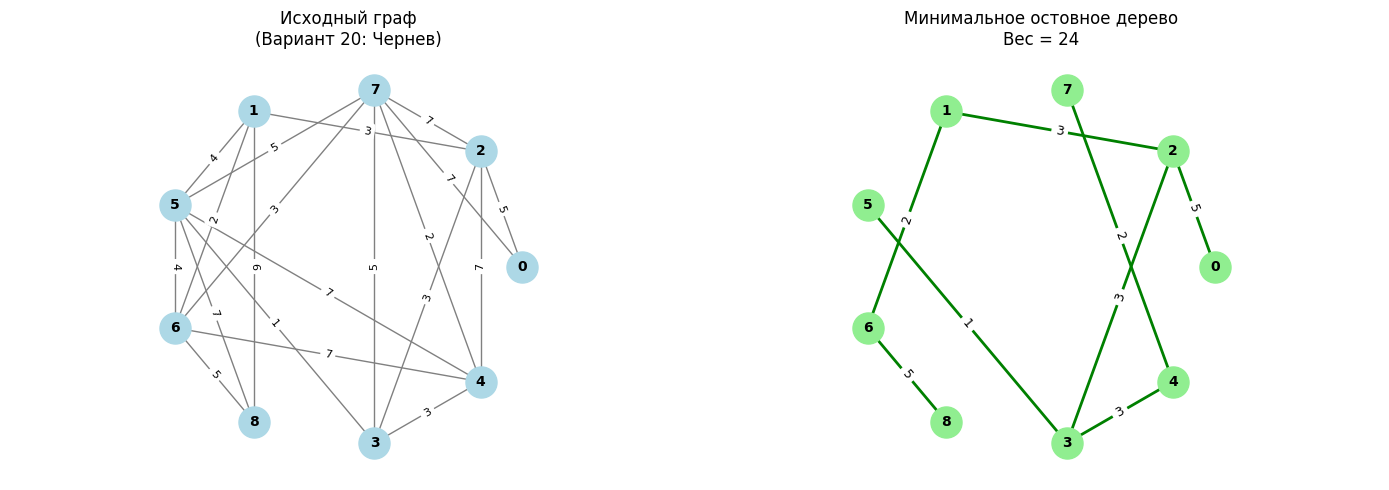

In [66]:
# Создаём граф для визуализации
G = nx.Graph()
n = len(adj_matrix)

# Добавляем все рёбра
for i in range(n):
    G.add_node(i)
    for j in range(i + 1, n):
        if adj_matrix[i, j] > 0:
            G.add_edge(i, j, weight=adj_matrix[i, j])

# Позиции вершин (круговая раскладка)
pos = nx.circular_layout(G)

# Рисуем исходный граф
plt.figure(figsize=(14, 5))

# Исходный граф
plt.subplot(1, 2, 1)
edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
nx.draw(G, pos, with_labels=True, node_color='lightblue', 
        node_size=500, font_size=10, font_weight='bold',
        edge_color='gray', width=1, ax=plt.gca())

# Подписи весов на рёбрах
labels = {edge: str(G[edge[0]][edge[1]]['weight']) for edge in G.edges()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, font_size=8, ax=plt.gca())

plt.title(f'Исходный граф\n(Вариант {variant}: {SURNAME})')
plt.axis('equal')

# МОД
plt.subplot(1, 2, 2)
MST = nx.Graph()
MST.add_nodes_from(range(n))
for u, v, w in mst_edges:
    MST.add_edge(u, v, weight=w)

nx.draw(MST, pos, with_labels=True, node_color='lightgreen',
        node_size=500, font_size=10, font_weight='bold',
        edge_color='green', width=2, ax=plt.gca())

mst_labels = {(u, v): str(w) for u, v, w in mst_edges}
nx.draw_networkx_edge_labels(MST, pos, edge_labels=mst_labels, font_size=9, ax=plt.gca())

plt.title(f'Минимальное остовное дерево\nВес = {mst_weight}')
plt.axis('equal')

plt.tight_layout()
plt.show()

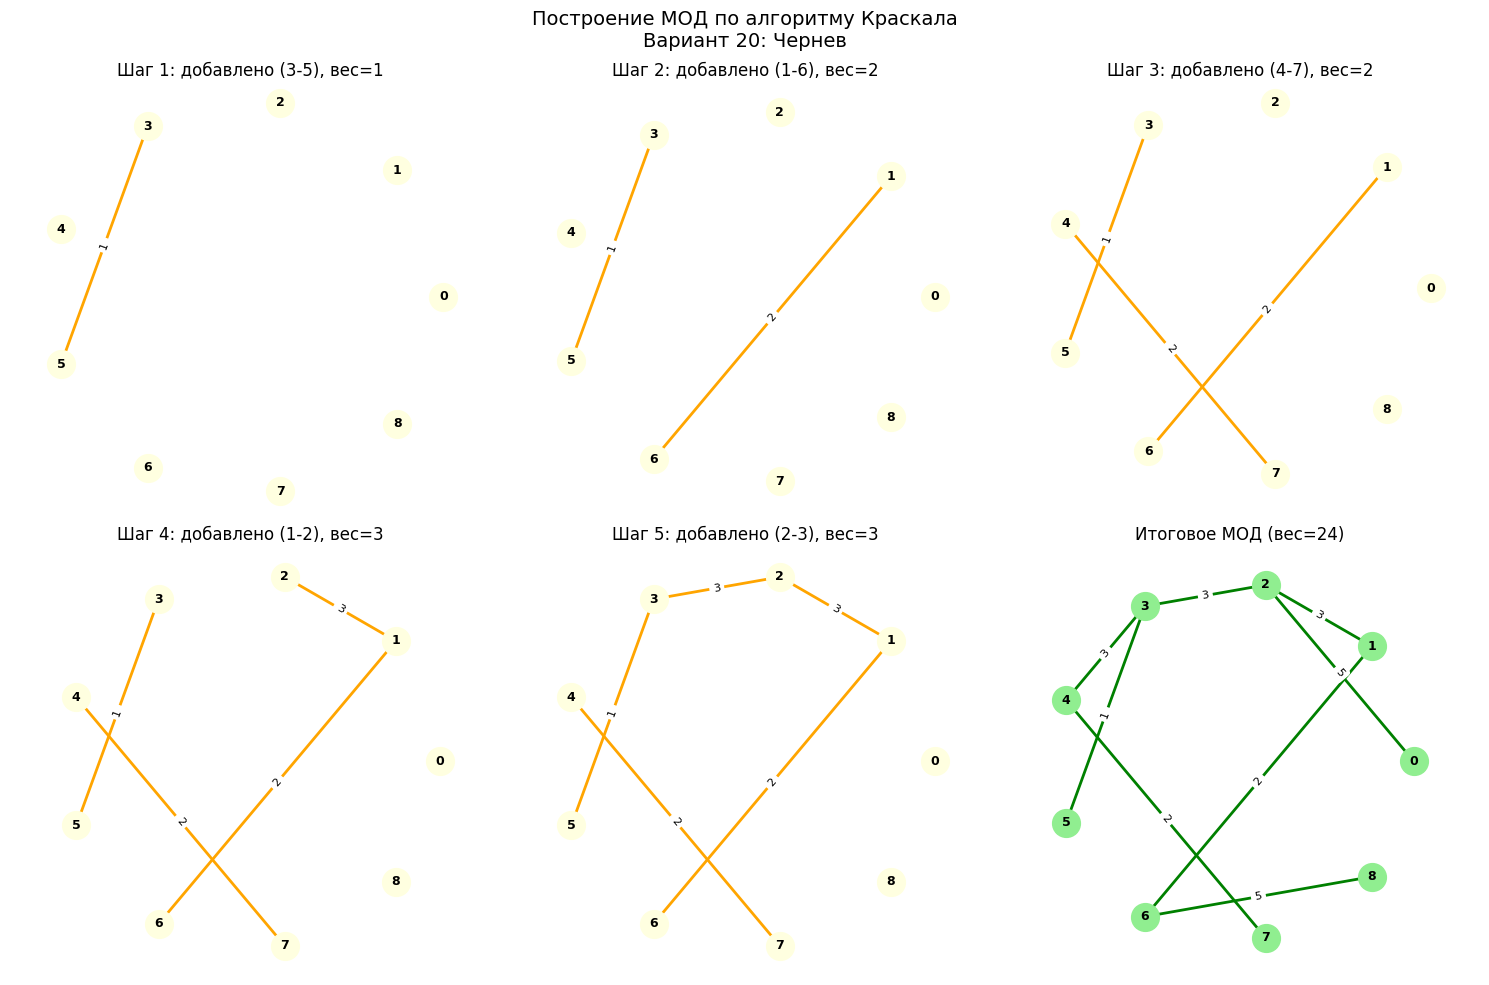

In [67]:
# Анимация построения МОД по шагам
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Показываем первые 5 шагов добавления рёбер
added_edges = []
step_indices = [i for i, s in enumerate(steps) if s['added']][:5]

for idx, step_idx in enumerate(step_indices):
    ax = axes[idx]
    step = steps[step_idx]
    
    # Строим граф с уже добавленными рёбрами
    current_G = nx.Graph()
    current_G.add_nodes_from(range(n))
    
    for i in range(step_idx + 1):
        if steps[i]['added']:
            u, v = steps[i]['edge']
            w = steps[i]['weight']
            current_G.add_edge(u, v, weight=w)
    
    pos = nx.circular_layout(current_G)
    nx.draw(current_G, pos, with_labels=True, node_color='lightyellow',
            node_size=400, font_size=9, font_weight='bold',
            edge_color='orange', width=2, ax=ax)
    
    # Подписи весов
    edge_list = list(current_G.edges())
    if edge_list:
        current_labels = {}
        for u, v in edge_list:
            for s in steps[:step_idx+1]:
                if s['added'] and set(s['edge']) == {u, v}:
                    current_labels[(u, v)] = str(s['weight'])
                    break
        nx.draw_networkx_edge_labels(current_G, pos, edge_labels=current_labels, font_size=8, ax=ax)
    
    u, v = step['edge']
    ax.set_title(f'Шаг {idx+1}: добавлено ({u}-{v}), вес={step["weight"]}')
    ax.axis('equal')

# Последний subplot - итоговое МОД
ax = axes[5]
nx.draw(MST, pos, with_labels=True, node_color='lightgreen',
        node_size=400, font_size=9, font_weight='bold',
        edge_color='green', width=2, ax=ax)
nx.draw_networkx_edge_labels(MST, pos, edge_labels=mst_labels, font_size=8, ax=ax)
ax.set_title(f'Итоговое МОД (вес={mst_weight})')
ax.axis('equal')

plt.suptitle(f'Построение МОД по алгоритму Краскала\nВариант {variant}: {SURNAME}', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Итоговые результаты

In [68]:
print("\n" + "="*60)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ")
print("="*60)
print(f"\nСтудент: {fio}")
print(f"Вариант: {variant}")
print(f"\n1. Матрица Кирхгофа: построена (см. выше)")
print(f"2. Количество остовных деревьев: {num_trees:,}")
print(f"3. Алгоритм Краскала:")
print(f"   - Найдено минимальное остовное дерево")
print(f"   - Рёбра МОД: {mst_edges}")
print(f"   - Вес МОД: {mst_weight}")
print("\n" + "="*60)


ИТОГОВЫЕ РЕЗУЛЬТАТЫ

Студент: Чернев Н А
Вариант: 20

1. Матрица Кирхгофа: построена (см. выше)
2. Количество остовных деревьев: 3,304,071,765
3. Алгоритм Краскала:
   - Найдено минимальное остовное дерево
   - Рёбра МОД: [(3, 5, np.int64(1)), (1, 6, np.int64(2)), (4, 7, np.int64(2)), (1, 2, np.int64(3)), (2, 3, np.int64(3)), (3, 4, np.int64(3)), (0, 2, np.int64(5)), (6, 8, np.int64(5))]
   - Вес МОД: 24

